#**Sector-Specific Government Policy Tracker**

OVERVIEW: This project demonstrates a basic ETL pipeline and analysis of US agency policy documents that may affect the tech industry. Sequentially, it:
1. Pulls all Federal Register documents instances within the past 6 months
2. Basic cleaning/munging
3. Fetching the actual documents themselves.
4. Transformer based model comparison to a given topic, industry, sector, etc.

Step 1. Data Pull

In [52]:
import requests
import pandas as pd
import datetime
import matplotlib.pyplot as plt
from bs4 import BeautifulSoup
import time
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity
from tqdm.auto import tqdm

In [53]:
#Preemptively
pd.set_option('display.max_columns', None)

In [75]:
#Calculate the date for six months ago
six_months_ago = (datetime.date.today() - datetime.timedelta(days=180)).isoformat()

#define API endpoint - This is quite long because the basic request doesn't pull all fields, and for exploratory reasons I'd like to take a look at them all.

#Here, we filter out notices, since these are usually junk
url = 'https://www.federalregister.gov/api/v1/documents.json?fields[]=abstract&fields[]=action&fields[]=agencies&fields[]=agency_names&fields[]=cfr_topics&fields[]=citation&fields[]=comments_close_on&fields[]=correction_of&fields[]=dates&fields[]=document_number&fields[]=effective_on&fields[]=end_page&fields[]=excerpts&fields[]=executive_order_notes&fields[]=executive_order_number&fields[]=explanation&fields[]=full_text_xml_url&fields[]=president&fields[]=presidential_document_number&fields[]=proclamation_number&fields[]=public_inspection_pdf_url&fields[]=publication_date&fields[]=raw_text_url&fields[]=significant&fields[]=signing_date&fields[]=start_page&fields[]=subtype&fields[]=title&fields[]=toc_doc&fields[]=toc_subject&fields[]=topics&fields[]=type&conditions[type][]=RULE&conditions[type][]=PRORULE&conditions[type][]=PRESDOCU&fields[]=volume&per_page='

params = {
    'per_page': 1000,
    'conditions[publication_date][gte]': six_months_ago
}

#Fetch
response = requests.get(url, params=params)
response.raise_for_status()
data = response.json()

data['results'][0] #Let's take a look at a response

{'description': 'Documents published on or after 12/21/2025 and of type Rule, Proposed Rule, and Presidential Document', 'count': 2376, 'total_pages': 3, 'next_page_url': 'https://www.federalregister.gov/api/v1/documents?conditions%5Bpublication_date%5D%5Bgte%5D=2025-12-21&conditions%5Btype%5D%5B%5D=RULE&conditions%5Btype%5D%5B%5D=PRORULE&conditions%5Btype%5D%5B%5D=PRESDOCU&fields%5B%5D=abstract&fields%5B%5D=action&fields%5B%5D=agencies&fields%5B%5D=agency_names&fields%5B%5D=cfr_topics&fields%5B%5D=citation&fields%5B%5D=comments_close_on&fields%5B%5D=correction_of&fields%5B%5D=dates&fields%5B%5D=document_number&fields%5B%5D=effective_on&fields%5B%5D=end_page&fields%5B%5D=excerpts&fields%5B%5D=executive_order_notes&fields%5B%5D=executive_order_number&fields%5B%5D=explanation&fields%5B%5D=full_text_xml_url&fields%5B%5D=president&fields%5B%5D=presidential_document_number&fields%5B%5D=proclamation_number&fields%5B%5D=public_inspection_pdf_url&fields%5B%5D=publication_date&fields%5B%5D=raw_

{'abstract': None,
 'action': None,
 'agencies': [{'raw_name': 'EXECUTIVE OFFICE OF THE PRESIDENT',
   'name': 'Executive Office of the President',
   'id': 538,
   'url': 'https://www.federalregister.gov/agencies/executive-office-of-the-president',
   'json_url': 'https://www.federalregister.gov/api/v1/agencies/538',
   'parent_id': None,
   'slug': 'executive-office-of-the-president'}],
 'agency_names': ['Executive Office of the President'],
 'cfr_topics': [],
 'citation': '91 FR 36961',
 'comments_close_on': None,
 'correction_of': None,
 'dates': None,
 'document_number': '2026-12436',
 'effective_on': None,
 'end_page': 36962,
 'excerpts': None,
 'executive_order_notes': None,
 'executive_order_number': None,
 'full_text_xml_url': 'https://www.federalregister.gov/documents/full_text/xml/2026/06/18/2026-12436.xml',
 'president': {'identifier': 'donald-trump', 'name': 'Donald Trump'},
 'presidential_document_number': '11037',
 'proclamation_number': '11037',
 'public_inspection_pdf_

Now let's flatten the data for readability's sake

In [76]:
#Flatten
df = pd.json_normalize(data['results'])

print(f"Retrieved {len(df)} documents.")
display(df.head())

Retrieved 1000 documents.


,abstract,action,agencies,agency_names,cfr_topics,citation,comments_close_on,correction_of,dates,document_number,effective_on,end_page,excerpts,executive_order_notes,executive_order_number,full_text_xml_url,presidential_document_number,proclamation_number,public_inspection_pdf_url,publication_date,raw_text_url,significant,signing_date,start_page,subtype,title,toc_doc,toc_subject,topics,type,volume,president.identifier,president.name
0,None,None,[{'raw_name': 'EXECUTIVE OFFICE OF THE PRESIDE...,[Executive Office of the President],[],91 FR 36961,None,None,None,2026-12436,None,36962,None,None,None,https://www.federalregister.gov/documents/full...,11037,11037,https://public-inspection.federalregister.gov/...,2026-06-18,https://www.federalregister.gov/documents/full...,None,2026-06-12,36961,Proclamation,"Flag Day and National Flag Week, 2026",Flag Day and National Flag Week (Proc. 11037),Special Observances,[],Presidential Document,91,donald-trump,Donald Trump
1,None,None,[{'raw_name': 'EXECUTIVE OFFICE OF THE PRESIDE...,[Executive Office of the President],[],91 FR 36959,None,None,None,2026-12435,None,36960,None,None,None,https://www.federalregister.gov/documents/full...,11036,11036,https://public-inspection.federalregister.gov/...,2026-06-18,https://www.federalregister.gov/documents/full...,None,2026-06-12,36959,Proclamation,"National Homeownership Month, 2026",National Homeownership Month (Proc. 11036),Special Observances,[],Presidential Document,91,donald-trump,Donald Trump
2,The Secretary waives the requirements in the E...,Final waivers and extensions of project period...,"[{'raw_name': 'DEPARTMENT OF EDUCATION', 'name...",[Education Department],[],91 FR 36750,None,None,These waivers and extensions of the project pe...,2026-12376,2026-07-20,36752,The Secretary waives the requirements in the E...,None,None,https://www.federalregister.gov/documents/full...,None,None,https://public-inspection.federalregister.gov/...,2026-06-18,https://www.federalregister.gov/documents/full...,None,None,36750,None,Final Waivers and Extensions of the Project Pe...,American Indian Vocational Rehabilitation Serv...,Final Waivers and Extensions of the Project Pe...,[],Rule,91,donald-trump,Donald Trump
3,The FAA proposes to adopt a new airworthiness ...,Notice of proposed rulemaking (NPRM).,"[{'raw_name': 'DEPARTMENT OF TRANSPORTATION', ...","[Transportation Department, Federal Aviation A...","[{'cfr_part': '39', 'topics': ['Air transporta...",91 FR 36771,2026-08-03,None,The FAA must receive comments on this NPRM by ...,2026-12362,None,36774,The FAA proposes to adopt a new airworthiness ...,None,None,https://www.federalregister.gov/documents/full...,None,None,https://public-inspection.federalregister.gov/...,2026-06-18,https://www.federalregister.gov/documents/full...,False,None,36771,None,Airworthiness Directives; Airbus Helicopters,Airbus Helicopters,Airworthiness Directives,"[Air transportation, Aircraft, Aviation safety...",Proposed Rule,91,donald-trump,Donald Trump
4,This request for information (RFI) solicits te...,Request for information.,[{'raw_name': 'DEPARTMENT OF HEALTH AND HUMAN ...,"[Health and Human Services Department, Centers...",[],91 FR 36776,2026-07-20,None,"To be assured consideration, comments must be ...",2026-12344,None,36779,This request for information (RFI) solicits te...,None,None,https://www.federalregister.gov/documents/full...,None,None,https://public-inspection.federalregister.gov/...,2026-06-18,https://www.federalregister.gov/documents/full...,None,None,36776,None,Request for Information (RFI): Pharmacy Benefi...,Pharmacy Benefit Manager Compensation and Data...,Request for Information,[],Proposed Rule,91,donald-trump,Donald Trump


It appears that the endpoint doesn't immediately expose the entire text of a document itself, which we'll likely need for the best cosine similarity match later.

Let's grab that before we begin. it appears it can be fetched from the raw_text_url endpoint.

It appears that the columns ***document number*** and ***date*** can be used to extract individual full text documents. Let's write a function to do this.
- However, per the endpoint, publication_date must be in YYYY/MM/DD format. Let's create that now.

In [77]:
df['publication_date'] = pd.to_datetime(df['publication_date']).dt.strftime('%Y/%m/%d')
df['publication_date'][0]

'2026/06/18'

In [57]:
#Function to retrieve full text
def get_full_text(df, doc_num, date):
  full_text_url = f'https://www.federalregister.gov/documents/full_text/xml/{date}/{doc_num}.xml'
  response = requests.get(full_text_url)
  return response.text

#Test
get_full_text(df, df['document_number'][0], df['publication_date'][0])

'<PRESDOCU>\n            <PROCLA>\n                <PRTPAGE P="36961"/>\n                <PROC>Proclamation 11037 of June 12, 2026</PROC>\n                <HD SOURCE="HED">Flag Day and National Flag Week, 2026</HD>\n                <PRES>By the President of the United States of America</PRES>\n                <PROC>A Proclamation</PROC>\n                <FP>On June 14, 1777, the delegates of the Second Continental Congress adopted a resolution declaring â\x80\x9cthat the flag of the United States be thirteen stripes, alternate red and white; that the union be thirteen stars, white in a blue field, representing a new Constellation.â\x80\x9d In the 250th year of our glorious Republic, this Flag Day celebrates the American People, whose enduring spirit allows our beloved and timeless tricolor standard to fly as the greatest symbol of freedom, democracy, and sovereign strength the world has ever known.</FP>\n                <FP>At its inception, the Stars and Stripes symbolized America\'s 

**Step 2 - Cleaning and Munging**

Now that our data is tabular - we can actually begin to understand it and evaluate it for cleaning.

**NOTE**: For the explicit purposes of this project, the only inputs we will ultimately need are two lists:
- A list/desc of sectors
- A list of text to match against via our bi-encoder model.

However, for the sake of this exercise, let's do some basic cleaning anyway - who knows, we might need it later.

In [59]:
#Check for irrelevant/less useful columns
df_cols_check = df.isna().sum()

It looks like our data has a lot of empty cols - let's retain the raw data, but make a copy that's easier to work with that excludes cols > 99% null.

- **NOTE**: It should be noted that contextually, sometimes we would want to keep columns like this. However, for this specific purpose, we're fine to remove.

In [60]:
df_cols_check = df.isna().sum() #Check empties
df_cols_GT_99_percent_empty = df_cols_check[df_cols_check > df.shape[0] * .99] #Flag emptys > 99%

df_cols_to_remove = df_cols_GT_99_percent_empty.index.to_list() #These are the cols we'll remove

print(df_cols_to_remove)

['correction_of', 'executive_order_notes', 'executive_order_number', 'presidential_document_number', 'proclamation_number', 'signing_date', 'subtype']


In [61]:
df2 = df.drop(columns=df_cols_to_remove).copy() #Drop the cols
df2.head()

,abstract,action,agencies,agency_names,cfr_topics,citation,comments_close_on,dates,document_number,effective_on,end_page,excerpts,full_text_xml_url,public_inspection_pdf_url,publication_date,raw_text_url,significant,start_page,title,toc_doc,toc_subject,topics,type,volume,president.identifier,president.name
0,None,None,[{'raw_name': 'EXECUTIVE OFFICE OF THE PRESIDE...,[Executive Office of the President],[],91 FR 36961,None,None,2026-12436,None,36962,None,https://www.federalregister.gov/documents/full...,https://public-inspection.federalregister.gov/...,2026/06/18,https://www.federalregister.gov/documents/full...,None,36961,"Flag Day and National Flag Week, 2026",Flag Day and National Flag Week (Proc. 11037),Special Observances,[],Presidential Document,91,donald-trump,Donald Trump
1,None,None,[{'raw_name': 'EXECUTIVE OFFICE OF THE PRESIDE...,[Executive Office of the President],[],91 FR 36959,None,None,2026-12435,None,36960,None,https://www.federalregister.gov/documents/full...,https://public-inspection.federalregister.gov/...,2026/06/18,https://www.federalregister.gov/documents/full...,None,36959,"National Homeownership Month, 2026",National Homeownership Month (Proc. 11036),Special Observances,[],Presidential Document,91,donald-trump,Donald Trump
2,The Secretary waives the requirements in the E...,Final waivers and extensions of project period...,"[{'raw_name': 'DEPARTMENT OF EDUCATION', 'name...",[Education Department],[],91 FR 36750,None,These waivers and extensions of the project pe...,2026-12376,2026-07-20,36752,The Secretary waives the requirements in the E...,https://www.federalregister.gov/documents/full...,https://public-inspection.federalregister.gov/...,2026/06/18,https://www.federalregister.gov/documents/full...,None,36750,Final Waivers and Extensions of the Project Pe...,American Indian Vocational Rehabilitation Serv...,Final Waivers and Extensions of the Project Pe...,[],Rule,91,donald-trump,Donald Trump
3,The FAA proposes to adopt a new airworthiness ...,Notice of proposed rulemaking (NPRM).,"[{'raw_name': 'DEPARTMENT OF TRANSPORTATION', ...","[Transportation Department, Federal Aviation A...","[{'cfr_part': '39', 'topics': ['Air transporta...",91 FR 36771,2026-08-03,The FAA must receive comments on this NPRM by ...,2026-12362,None,36774,The FAA proposes to adopt a new airworthiness ...,https://www.federalregister.gov/documents/full...,https://public-inspection.federalregister.gov/...,2026/06/18,https://www.federalregister.gov/documents/full...,False,36771,Airworthiness Directives; Airbus Helicopters,Airbus Helicopters,Airworthiness Directives,"[Air transportation, Aircraft, Aviation safety...",Proposed Rule,91,donald-trump,Donald Trump
4,This request for information (RFI) solicits te...,Request for information.,[{'raw_name': 'DEPARTMENT OF HEALTH AND HUMAN ...,"[Health and Human Services Department, Centers...",[],91 FR 36776,2026-07-20,"To be assured consideration, comments must be ...",2026-12344,None,36779,This request for information (RFI) solicits te...,https://www.federalregister.gov/documents/full...,https://public-inspection.federalregister.gov/...,2026/06/18,https://www.federalregister.gov/documents/full...,None,36776,Request for Information (RFI): Pharmacy Benefi...,Pharmacy Benefit Manager Compensation and Data...,Request for Information,[],Proposed Rule,91,donald-trump,Donald Trump


Documents of type "Notice" aren't important for our purposes - these include lesser agency-specific things, such as meeting announcements. This would likely be noise in eventual results for our tracker.

In [62]:
df2 = df2[~df2['type'].str.contains('Notice', case=False, na=False)]
df2['type'].value_counts() #Just making sure



Let's visualize publications over time and by agency, just to give ourselves a bit of context.

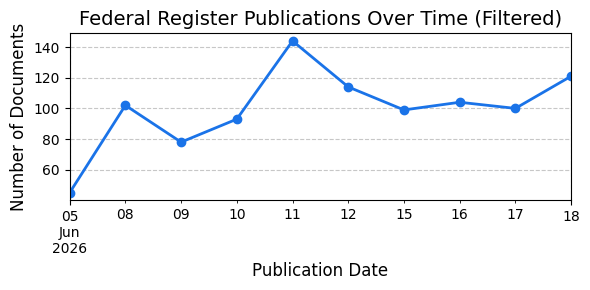

In [63]:
#Ensure publication_date is datetime for proper sorting
df_plot = df2.copy()
df_plot['publication_date'] = pd.to_datetime(df_plot['publication_date'])

#Group by date and count publications
daily_counts = df_plot.groupby('publication_date').size()

#Plotting
plt.figure(figsize=(6, 3))
daily_counts.plot(kind='line', marker='o', color='#1a73e8', linewidth=2)
plt.title('Federal Register Publications Over Time (Filtered)', fontsize=14)
plt.xlabel('Publication Date', fontsize=12)
plt.ylabel('Number of Documents', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

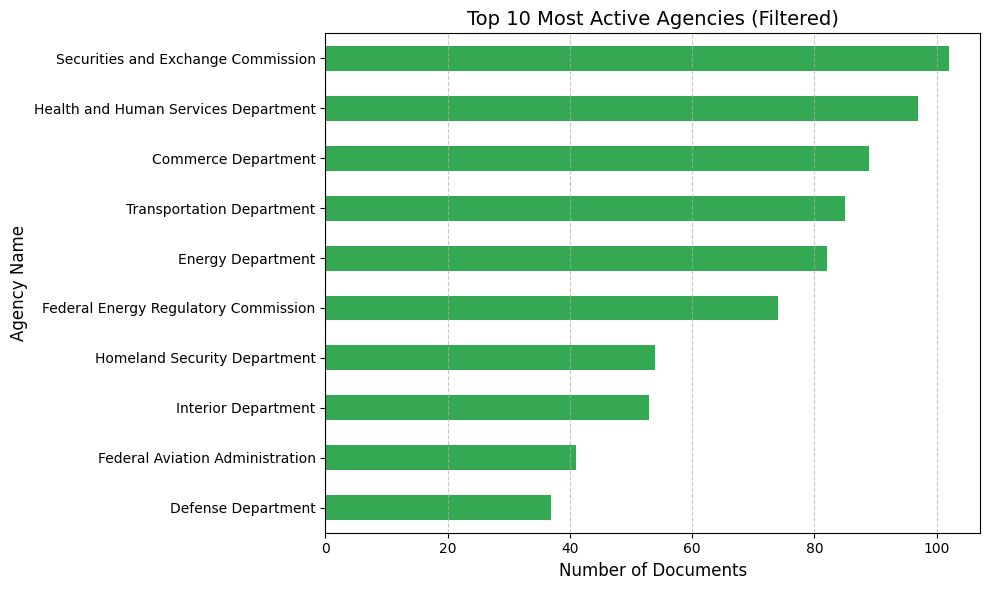

In [64]:
#Explode the agency_names list to count individual agency occurrences
agency_counts = df2['agency_names'].explode().value_counts().head(10)

#Plotting
plt.figure(figsize=(10, 6))
agency_counts.plot(kind='barh', color='#34a853')
plt.title('Top 10 Most Active Agencies (Filtered)', fontsize=14)
plt.xlabel('Number of Documents', fontsize=12)
plt.ylabel('Agency Name', fontsize=12)
plt.gca().invert_yaxis()  #Put the highest count at the top
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [65]:
#Let's see what a single document looks like
def fetch_full_text_doc(url):
  """
  Fetches singular FR doc, returns as xml, and parses Federal Register XML and concatenates text from all <FP> tags: FP indicates the actual text
  """
  response = requests.get(url)
  doc_xml =  response.text
  soup = BeautifulSoup(doc_xml, 'xml')
  fp_tags = soup.find_all('FP')
  # Extract text from each tag and join with spaces
  clean_text = " ".join([tag.get_text(strip=True) for tag in fp_tags])
  return clean_text

sample = fetch_full_text_doc('https://www.federalregister.gov/documents/full_text/xml/2026/06/18/2026-12435.xml')

sample

'During National Homeownership Month, my Administration recommits to making housing more affordable so that young Americans and hardworking families can raise children, build memories, and create a future in a home of their own. For too long, reckless spending, burdensome regulations, and failed housing policies drove up home prices and mortgage rates while mass illegal immigration and large institutional investors strained the housing supply. The result was a housing affordability crisis brought on by the failed leadership of the previous administration. Now, under my leadership, my Administration is fixing the mess we inherited and restoring the American Dream of homeownership. From the first day I returned to office, I proudly signed an Executive Order to deliver price relief to Americans crushed by the left-wing cost-of-living crisisâ\x80\x94launching a bold new era of progress on supply, affordability, and opportunity for every hardworking family across our country. My Administrat

It works - let's have it go through the whole dataframe.
- **NOTE**: Although normally using .map() would be quicker, in this case we're just going to make a loop to avoid any throttling risk.

In [67]:
# We will use a list to store the results then add to the dataframe
full_texts = []

print(f"Starting batch retrieval for {len(df2)} documents...")

# Loop over the filtered dataframe
for index, row in tqdm(df2.iterrows(), total=df2.shape[0]):
    url = row['full_text_xml_url']
    if pd.isna(url):
        full_texts.append("")
        continue

    try:
        # Using the helper function defined in the previous cell
        text = fetch_full_text_doc(url)
        full_texts.append(text)
    except Exception as e:
        print(f"Error fetching index {index}: {e}")
        full_texts.append("")

    # Sleep for 3 seconds to avoid throttling
    time.sleep(0.5)

# Assign the results to a new column
df2['full_text'] = full_texts


print("Done! Full text column added.")
display(df2[['title', 'full_text']].head())

Starting batch retrieval for 1000 documents...


  0%|          | 0/1000 [00:00<?, ?it/s]

Done! Full text column added.


,title,full_text
0,"Flag Day and National Flag Week, 2026","On June 14, 1777, the delegates of the Second ..."
1,"National Homeownership Month, 2026","During National Homeownership Month, my Admini..."
2,Final Waivers and Extensions of the Project Pe...,
3,Airworthiness Directives; Airbus Helicopters,Airbus Helicopters:Docket No. FAA-2026-4657; P...
4,Request for Information (RFI): Pharmacy Benefi...,++ Affiliated provider group ++ Data vendors +...


Now we have our dataframe, complete enough for our purposes. Let's extract the full text articles for input

In [ ]:
industry_profile_semis = """
Semiconductor manufacturing, chip fabrication,
advanced packaging, wafer processing,
photolithography, foundries, integrated circuits,
microelectronics supply chain, semiconductor workforce
"""


industry_profile_ai = """Organizations developing, deploying, or using artificial intelligence technologies, including machine learning, generative AI, large language models, computer vision, natural language processing, AI infrastructure, model training, AI safety, and responsible AI governance."""


industry_profile_biotech = """This cluster encompasses federal oversight of healthcare delivery, medical innovation, biomedical research, and reimbursement systems. Regulatory activity spans medical device approvals, pharmaceutical oversight, clinical research governance, Medicare and Medicaid payment structures, health information management, and public-health reporting requirements. The sector sits at the intersection of patient safety, scientific advancement, and healthcare economics, making it one of the most consistently active areas of federal rulemaking. Changes in this domain can affect hospitals, insurers, biotechnology firms, medical-device manufacturers, pharmaceutical companies, research institutions, and healthcare technology vendors."""

industry_profile_cybersecurity = """Cybersecurity regulation increasingly functions as a cross-sector governance framework rather than a standalone technology issue. Federal actions in this space address cyber risk management, incident reporting, software security, supply-chain resilience, operational technology protection, and security standards for critical infrastructure operators. The sector reflects growing concerns that cyber incidents can disrupt essential services such as energy, healthcare, transportation, telecommunications, and financial systems. As a result, cybersecurity requirements are becoming embedded into broader compliance and enterprise-risk management programs across the economy."""

industry_profile_energy = """This theme encompasses the production, transmission, regulation, and security of energy resources and supporting infrastructure. Federal activity frequently addresses power generation, grid reliability, nuclear licensing, infrastructure modernization, operational safety, and resilience planning. Many regulatory initiatives are driven by concerns over energy security, reliability, technological modernization, and long-term capacity needs. Stakeholders include utilities, independent power producers, infrastructure developers, engineering firms, nuclear operators, and large industrial energy consumers."""

industry_profile_maritime_transport = """Transportation-related rulemaking focuses on the safe, efficient, and reliable movement of people and goods. Federal actions can involve vehicle safety standards, maritime operations, logistics systems, transportation infrastructure, regulatory compliance requirements, and operational risk management. The sector plays a foundational role in economic activity because transportation networks connect supply chains, labor markets, and consumer demand. Regulatory changes often seek to improve safety, efficiency, resilience, and interoperability across transportation modes."""

In [70]:
model = SentenceTransformer("all-MiniLM-L6-v2")

query = industry_profile_cybersecurity

query_emb = model.encode([query])

doc_embs = model.encode(
    df2["full_text"].fillna("").tolist(),
    show_progress_bar=True
)

scores = cosine_similarity(query_emb, doc_embs)[0]

df2["similarity"] = scores

results = df2.sort_values("similarity", ascending=False)

# Display the top matches
display(results[["title", "agency_names", "similarity"]].head(10))

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Batches:   0%|          | 0/32 [00:00<?, ?it/s]

,title,agency_names,similarity
955,Promoting Advanced Artificial Intelligence Inn...,[Executive Office of the President],0.624062
890,International Energy Agency Meetings,[Energy Department],0.401576
496,Drawbridge Operation Regulation; Big Carlos Pa...,"[Homeland Security Department, Coast Guard]",0.397039
170,Special Local Regulation; Marine Events Within...,"[Homeland Security Department, Coast Guard]",0.395732
543,"Special Local Regulation; Ohio River, Henderso...","[Homeland Security Department, Coast Guard]",0.391907
735,Strengthening Customs Enforcement,[Executive Office of the President],0.391738
889,Anchorages; Port of New York,"[Homeland Security Department, Coast Guard]",0.386425
343,"Security Zone; Santa Monica Bay, Los Angeles, CA","[Homeland Security Department, Coast Guard]",0.386425
610,"Safety Zone; Maumee River, Perrysburg, OH","[Homeland Security Department, Coast Guard]",0.386425
824,"Safety Zone; Fireworks Displays, Laguna Madre,...","[Homeland Security Department, Coast Guard]",0.386425
